# Knowledge Distillation: v6 Teacher → MobileNetV3-Large Student

**Goal:** Compress the 92.71% v6 ensemble into a single ~5M-param MobileNetV3-Large
that runs on raw images and can be exported to ONNX for web/mobile deployment.

**Teacher:** Full v6 pipeline (10-head CoinHeadV6 ensemble + 5 sub-classifiers) — 92.71% test accuracy  
**Student:** MobileNetV3-Large pretrained on ImageNet, fine-tuned with distillation loss  
**Export:** ONNX → int8 quantization → ~4-5MB model ready for onnxruntime-web

### How it works
1. **Pre-compute teacher soft labels** — run the full v6 pipeline on all 62K embeddings once,
   save the probability distributions to disk. Teacher is never used again during student training.
2. **Student trains on raw images** — MobileNetV3 processes 224×224 coin images with live augmentation.
3. **Distillation loss** — blend of:
   - `α × T² × KL(student_soft || teacher_soft)` — learn the teacher's uncertainty over similar emperors
   - `(1-α) × CE(student, hard_label)` — still anchored to the ground truth
4. **ONNX export** — single forward pass, no ensemble, no kNN, no backbone switching.

**Key advantage of soft labels:** The teacher assigns ~5-15% probability to visually similar
emperors (e.g. SEPTIMUS SEVERUS when the true label is DIDIUS JULIANUS). The student learns
this calibrated uncertainty rather than a hard 0/1 signal — better generalisation on hard pairs.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab.')

Not running on Colab.


In [3]:
DATA_DIR = r'/content/drive/MyDrive/coin_dataset' if ON_COLAB else r'/home/david/coin/FOR_TRAINNING'

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def folder_label(name):
    return re.sub(r'^\d+_', '', name)

image_dir     = Path(DATA_DIR)
filepaths     = sorted(image_dir.glob('*/side_a/*.jpg'))   # same order as embeddings
unique_labels = sorted({folder_label(p.parent.parent.name) for p in filepaths})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
raw_labels    = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int    = [label_encoder[l] for l in raw_labels]
print(f'{len(filepaths)} images  |  {len(label_encoder)} raw classes')

# Apply the same GORDIAN II merge used in all previous versions
MERGES = {'GORDIAN II': 'GORDIAN I'}
kept_names        = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new        = {label_encoder[name]: new_label_encoder[name] for name in kept_names}
for src, tgt in MERGES.items():
    old_to_new[label_encoder[src]] = new_label_encoder[tgt]

all_labs      = torch.tensor([old_to_new[l] for l in labels_int], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'After merge: {num_classes} classes')

Device: cuda:0
62134 images  |  52 raw classes
After merge: 51 classes


---
## Section A — Pre-compute Teacher Soft Labels

Load the full v6 pipeline (ensemble + sub-classifiers) and run it on all 62K embeddings.
Save the resulting probability distributions — these are the soft targets for distillation.

This cell only needs to run once. If `teacher_soft_labels.pt` already exists, skip it.

In [4]:
# ── v6 architecture (copied from emp_model_v6.ipynb) ──────────────────────────
class ArcFaceClassifier(nn.Module):
    def __init__(self, in_dim, n_cls, scale=20.0, margin=0.2):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim))
        nn.init.xavier_uniform_(self.weight)
        self.scale = scale; self.margin = margin

    def forward(self, x, labels=None):
        x = F.normalize(x, dim=-1)
        w = F.normalize(self.weight, dim=-1)
        cos = x @ w.T
        if labels is None or not self.training:
            return self.scale * cos
        theta = cos.clamp(-1 + 1e-7, 1 - 1e-7).acos()
        target_cos = (theta + self.margin).cos()
        one_hot = torch.zeros_like(cos).scatter_(1, labels.unsqueeze(1), 1.0)
        return self.scale * (one_hot * target_cos + (1 - one_hot) * cos)


class StreamProjector(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.LayerNorm(in_dim), nn.Linear(in_dim, out_dim), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x): return self.proj(x)


class CoinHeadV6(nn.Module):
    def __init__(self, n_cls, full_dim=3840, portrait_dim=2560, legend_dim=2560,
                 proj_full=1024, proj_crop=512, hidden=2048, dropout=0.3):
        super().__init__()
        self.proj_full     = StreamProjector(full_dim,     proj_full, dropout=0.1)
        self.proj_portrait = StreamProjector(portrait_dim, proj_crop, dropout=0.1)
        self.proj_legend   = StreamProjector(legend_dim,   proj_crop, dropout=0.1)
        fused = proj_full + proj_crop + proj_crop
        self.body = nn.Sequential(
            nn.LayerNorm(fused), nn.Linear(fused, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls)

    def forward(self, x_full, x_portrait, x_legend, labels=None):
        fused = torch.cat([
            self.proj_full(x_full),
            self.proj_portrait(x_portrait),
            self.proj_legend(x_legend),
        ], dim=-1)
        return self.cls(self.body(fused), labels)


class SubHead(nn.Module):
    def __init__(self, in_dim, n_cls, hidden=512, dropout=0.2, margin=0.4, scale=25.0):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim), nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls, scale=scale, margin=margin)

    def forward(self, x, labels=None):
        return self.cls(self.body(x), labels)


print('v6 architecture defined.')

v6 architecture defined.


In [5]:
soft_labels_path = Path(DATA_DIR) / 'teacher_soft_labels.pt'

if soft_labels_path.exists():
    print('Teacher soft labels already on disk — skipping generation.')
else:
    # ── Load embeddings ────────────────────────────────────────────────────────
    v41_data   = torch.load(Path(DATA_DIR) / 'cradio_v41_embeddings.pt')
    crops_data = torch.load(Path(DATA_DIR) / 'cradio_v5_crops.pt')

    feats_full     = v41_data['features'].to(device)       # (N, 3840)
    feats_portrait = crops_data['features_portrait'].to(device)  # (N, 2560)
    feats_legend   = crops_data['features_legend'].to(device)    # (N, 2560)
    print(f'Embeddings loaded: {feats_full.shape[0]} images')

    # ── Load v6 main ensemble ──────────────────────────────────────────────────
    ensemble_states = torch.load('emp_model_v6_ensemble.pth', map_location=device)
    teacher_ensemble = []
    for state in ensemble_states:
        m = CoinHeadV6(num_classes).to(device)
        m.load_state_dict(state)
        m.eval()
        teacher_ensemble.append(m)
    print(f'Loaded {len(teacher_ensemble)}-head main ensemble.')

    # ── Load v6 sub-classifiers ────────────────────────────────────────────────
    sub_save   = torch.load('emp_model_v6_sub.pth', map_location=device)
    HARD_PAIR_CLUSTERS = {
        'QAC':          ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
        'VAG':          ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
        'SDP':          ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
        'TETRARCHY':    ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
        'SEVERAN_HARD': ['ELAGABALUS', 'CARACALLA', 'GETA'],
    }
    # Per-cluster sub_weights tuned in v6
    SUB_WEIGHTS = {'QAC': 0.7, 'VAG': 0.9, 'SDP': 0.8, 'TETRARCHY': 0.2, 'SEVERAN_HARD': 1.0}

    sub_classifiers = {}
    for name, info in sub_save.items():
        cluster_idxs = info['idxs']
        sub_ens = []
        for state in info['states']:
            m = SubHead(3840, len(cluster_idxs)).to(device)
            m.load_state_dict(state)
            m.eval()
            sub_ens.append(m)
        sub_classifiers[name] = {'ensemble': sub_ens, 'idxs': cluster_idxs}
    print(f'Loaded sub-classifiers: {list(sub_classifiers.keys())}')

    # ── Run full v6 pipeline on all images ─────────────────────────────────────
    BATCH = 512
    N     = feats_full.shape[0]
    all_soft = torch.zeros(N, num_classes)

    with torch.no_grad():
        for start in range(0, N, BATCH):
            end    = min(start + BATCH, N)
            xf     = feats_full[start:end]
            xp     = feats_portrait[start:end]
            xl     = feats_legend[start:end]

            # Stage 1: main ensemble
            probs = None
            for m in teacher_ensemble:
                p     = F.softmax(m(xf, xp, xl), dim=-1)
                probs = p if probs is None else probs + p
            probs /= len(teacher_ensemble)

            # Stage 2: sub-classifier redistribution
            for cluster_name, info in sub_classifiers.items():
                sw = SUB_WEIGHTS.get(cluster_name, 0.0)
                if sw == 0.0:
                    continue
                cluster_idxs = info['idxs']
                sub_p = None
                for m in info['ensemble']:
                    p     = F.softmax(m(xf), dim=-1)
                    sub_p = p if sub_p is None else sub_p + p
                sub_p /= len(info['ensemble'])

                mass         = probs[:, cluster_idxs].sum(dim=-1, keepdim=True)
                redistributed = mass * sub_p
                blended       = (1 - sw) * probs[:, cluster_idxs] + sw * redistributed
                for local_i, global_i in enumerate(cluster_idxs):
                    probs[:, global_i] = blended[:, local_i]
                probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)

            all_soft[start:end] = probs.cpu()
            if (start // BATCH) % 10 == 0:
                print(f'  {end}/{N}')

    torch.save(all_soft, soft_labels_path)
    print(f'\nSaved teacher soft labels → {soft_labels_path}  shape={all_soft.shape}')

    # Cleanup
    del teacher_ensemble, sub_classifiers, feats_full, feats_portrait, feats_legend
    torch.cuda.empty_cache()

Embeddings loaded: 62134 images
Loaded 10-head main ensemble.
Loaded sub-classifiers: ['QAC', 'VAG', 'SDP', 'TETRARCHY', 'SEVERAN_HARD']
  512/62134
  5632/62134
  10752/62134
  15872/62134
  20992/62134
  26112/62134
  31232/62134
  36352/62134
  41472/62134
  46592/62134
  51712/62134
  56832/62134
  61952/62134

Saved teacher soft labels → /home/david/coin/FOR_TRAINNING/teacher_soft_labels.pt  shape=torch.Size([62134, 51])


---
## Section B — Student Dataset

Raw image dataset feeding MobileNetV3 (224×224, ImageNet normalisation).
The train/val/test split reproduces the exact indices used in v6 (same `random_state=42`).

Each sample: `(image_tensor, soft_label_vector, hard_label_int)`

In [6]:
# Reproduce the same split used in all previous versions
indices = np.arange(len(all_labs))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, shuffle=True, stratify=all_labs.numpy(), random_state=42)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, shuffle=True,
    stratify=all_labs.numpy()[train_idx], random_state=42)

print(f'Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')

# Load teacher soft labels
teacher_soft = torch.load(soft_labels_path)  # (N, 51) — full dataset
print(f'Teacher soft labels: {teacher_soft.shape}')

Train: 39765  Val: 9942  Test: 12427
Teacher soft labels: torch.Size([62134, 51])


In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(30),          # coins have no canonical orientation
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class CoinDistilDataset(Dataset):
    """Returns (image, soft_label, hard_label) for distillation training."""
    def __init__(self, indices, transform):
        self.indices   = indices
        self.transform = transform

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        idx        = self.indices[i]
        img        = Image.open(filepaths[idx]).convert('RGB')
        img_tensor = self.transform(img)
        soft       = teacher_soft[idx]            # (51,) float
        hard       = all_labs[idx]                # int
        return img_tensor, soft, hard


train_ds = CoinDistilDataset(train_idx, train_transform)
val_ds   = CoinDistilDataset(val_idx,   val_transform)
test_ds  = CoinDistilDataset(test_idx,  val_transform)
print(f'Datasets: train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')

Datasets: train=39765  val=9942  test=12427


In [8]:
BATCH_SIZE = 128

train_labs_idx    = all_labs[train_idx]
class_counts      = torch.bincount(train_labs_idx, minlength=num_classes).float()
beta              = 0.9999
effective_num     = 1.0 - torch.pow(beta, class_counts)
cb_weights        = (1.0 - beta) / effective_num
cb_weights        = cb_weights / cb_weights.sum() * num_classes

sample_weights = cb_weights[train_labs_idx]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_ds),
                                        replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
                           num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
print(f'Loaders ready. Batches per epoch: {len(train_loader)}')

Loaders ready. Batches per epoch: 311


---
## Section C — Student Model: MobileNetV3-Large

~5.4M params. Replace the final 1000-class head with a 51-class head.
Keep the ImageNet-pretrained backbone — this is transfer learning + distillation combined.

In [9]:
student = tvm.mobilenet_v3_large(weights=tvm.MobileNet_V3_Large_Weights.IMAGENET1K_V2)

# Replace final linear layer (1280 → 1000) with (1280 → 51)
in_features = student.classifier[3].in_features
student.classifier[3] = nn.Linear(in_features, num_classes)
student = student.to(device)

total_params = sum(p.numel() for p in student.parameters())
trainable    = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'MobileNetV3-Large: {total_params / 1e6:.1f}M total params ({trainable / 1e6:.1f}M trainable)')
print(f'Head: in_features={in_features} → {num_classes} classes')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/david/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 68.2MB/s]

MobileNetV3-Large: 4.3M total params (4.3M trainable)
Head: in_features=1280 → 51 classes


---
## Section D — Distillation Training

**Loss:** `α × T² × KL(student_soft || teacher_soft) + (1-α) × CE(student, hard_label)`

- `T=4` — temperature softens the student's output, making gradients smoother on uncertain examples
- `α=0.7` — teacher signal dominates; hard labels keep the student grounded
- `T²` factor compensates for reduced gradient magnitudes from temperature scaling

The teacher's soft labels already encode the hard-pair uncertainty learned by the v6 sub-classifiers
(e.g. DIDIUS JULIANUS → 25% SEPTIMUS SEVERUS). The student inherits this calibration for free.

In [10]:
EPOCHS    = 60
T_DISTIL  = 4.0    # temperature
ALPHA     = 0.7    # weight on soft (teacher) loss
LR        = 3e-4
WD        = 1e-4

cb_weights_dev = cb_weights.to(device)


def distillation_loss(student_logits, teacher_probs, hard_labels):
    # Soft loss — KL divergence, student softened by T
    student_log_soft = F.log_softmax(student_logits / T_DISTIL, dim=-1)
    soft_loss = F.kl_div(student_log_soft, teacher_probs,
                          reduction='batchmean') * (T_DISTIL ** 2)
    # Hard loss — class-balanced CE
    hard_loss = F.cross_entropy(student_logits, hard_labels,
                                 weight=cb_weights_dev)
    return ALPHA * soft_loss + (1 - ALPHA) * hard_loss


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


optimizer   = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WD)
total_steps = EPOCHS * len(train_loader)
scheduler   = make_scheduler(optimizer, total_steps, warmup_steps=2 * len(train_loader))

best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    t0 = datetime.now()
    student.train()
    running_loss = 0.0

    for imgs, soft_labels, hard_labels in train_loader:
        imgs, soft_labels, hard_labels = (
            imgs.to(device), soft_labels.to(device), hard_labels.to(device))
        optimizer.zero_grad()
        logits = student(imgs)
        loss   = distillation_loss(logits, soft_labels, hard_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    student.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, _, hard_labels in val_loader:
            imgs, hard_labels = imgs.to(device), hard_labels.to(device)
            correct += (student(imgs).argmax(-1) == hard_labels).sum().item()
            total   += hard_labels.size(0)
    val_acc  = correct / total
    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state   = copy.deepcopy(student.state_dict())

    if epoch <= 5 or epoch % 5 == 0 or improved:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'ep {epoch:3d}/{EPOCHS}  '
              f'loss {running_loss / len(train_loader):.4f}  '
              f'val {val_acc:.4f}  lr {lr_now:.2e}  '
              f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

student.load_state_dict(best_state)
student.eval()
torch.save(student.state_dict(), 'emp_model_distil_student.pth')
print(f'\nBest val acc: {best_val_acc:.4f}  —  saved student weights')

ep   1/60  loss 38.6730  val 0.2750  lr 1.50e-04  [0:01:03.976474] <--
ep   2/60  loss 16.9440  val 0.6080  lr 3.00e-04  [0:01:00.666347] <--
ep   3/60  loss 9.0483  val 0.7254  lr 3.00e-04  [0:00:59.289618] <--
ep   4/60  loss 6.3841  val 0.7729  lr 2.99e-04  [0:00:56.066852] <--
ep   5/60  loss 4.8364  val 0.7727  lr 2.98e-04  [0:00:59.593663]
ep   6/60  loss 3.9280  val 0.7937  lr 2.96e-04  [0:00:58.991177] <--
ep   7/60  loss 3.2859  val 0.8173  lr 2.95e-04  [0:00:57.104140] <--
ep   9/60  loss 2.3747  val 0.8369  lr 2.89e-04  [0:01:01.533635] <--
ep  10/60  loss 2.1098  val 0.8306  lr 2.86e-04  [0:00:57.667248]
ep  12/60  loss 1.6408  val 0.8436  lr 2.79e-04  [0:01:02.528262] <--
ep  13/60  loss 1.4590  val 0.8477  lr 2.74e-04  [0:01:02.609040] <--
ep  14/60  loss 1.3622  val 0.8581  lr 2.69e-04  [0:00:59.455053] <--
ep  15/60  loss 1.1824  val 0.8561  lr 2.64e-04  [0:01:01.206721]
ep  17/60  loss 0.9687  val 0.8634  lr 2.53e-04  [0:00:56.945017] <--
ep  20/60  loss 0.7926  val 0.

---
## Section E — Evaluation

In [11]:
student.eval()

def evaluate(loader, name):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, _, hard_labels in loader:
            imgs, hard_labels = imgs.to(device), hard_labels.to(device)
            correct += (student(imgs).argmax(-1) == hard_labels).sum().item()
            total   += hard_labels.size(0)
    acc = correct / total
    print(f'{name}: {acc:.4f}  ({correct}/{total})')
    return acc

val_acc  = evaluate(val_loader,  'Val ')
test_acc = evaluate(test_loader, 'Test')
print(f'\nTeacher (v6 full pipeline): 92.71%')
print(f'Student (MobileNetV3-Large): {test_acc * 100:.2f}%')
print(f'Compression gap: {(0.9271 - test_acc) * 100:.2f} pp')

Val : 0.8959  (8907/9942)
Test: 0.8961  (11136/12427)

Teacher (v6 full pipeline): 92.71%
Student (MobileNetV3-Large): 89.61%
Compression gap: 3.10 pp


Overall: 11136/12427 = 0.8961

Per-class (worst first):
41_QUINTILLUS: 55/140  (39.3%)
  -> 42_AURELIAN: 50 (35.7%)
  -> 40_CLAUDIUS GOTHICUS: 31 (22.1%)
38_VALERIAN: 69/122  (56.6%)
  -> 39_GALLIENUS: 24 (19.7%)
  -> 37_AEMILIAN: 17 (13.9%)
21_SEPTIMUS SEVERUS: 325/469  (69.3%)
  -> 20_DIDIUS JULIANUS: 122 (26.0%)
  -> 18_COMMODUS: 10 (2.1%)
37_AEMILIAN: 108/152  (71.1%)
  -> 38_VALERIAN: 32 (21.1%)
  -> 39_GALLIENUS: 7 (4.6%)
39_GALLIENUS: 123/163  (75.5%)
  -> 38_VALERIAN: 30 (18.4%)
  -> 37_AEMILIAN: 2 (1.2%)
36_TRBONIANUS GALLUS: 96/124  (77.4%)
  -> 33_PHILIP THE ARAB: 10 (8.1%)
  -> 34_TRAJAN DECIUS: 4 (3.2%)
50_MAXIMIAN: 166/203  (81.8%)
  -> 52_GALERIUS: 14 (6.9%)
  -> 49_DIOCLETIAN: 6 (3.0%)
51_CONSTANTIUS I: 85/103  (82.5%)
  -> 52_GALERIUS: 7 (6.8%)
  -> 49_DIOCLETIAN: 5 (4.9%)
25_ELAGABALUS: 267/321  (83.2%)
  -> 22_CARACALLA: 23 (7.2%)
  -> 26_SEVERUS ALEXANDER: 10 (3.1%)
53_SEVERUS II: 50/60  (83.3%)
  -> 52_GALERIUS: 5 (8.3%)
  -> 49_DIOCLETIAN: 2 (3.3%)


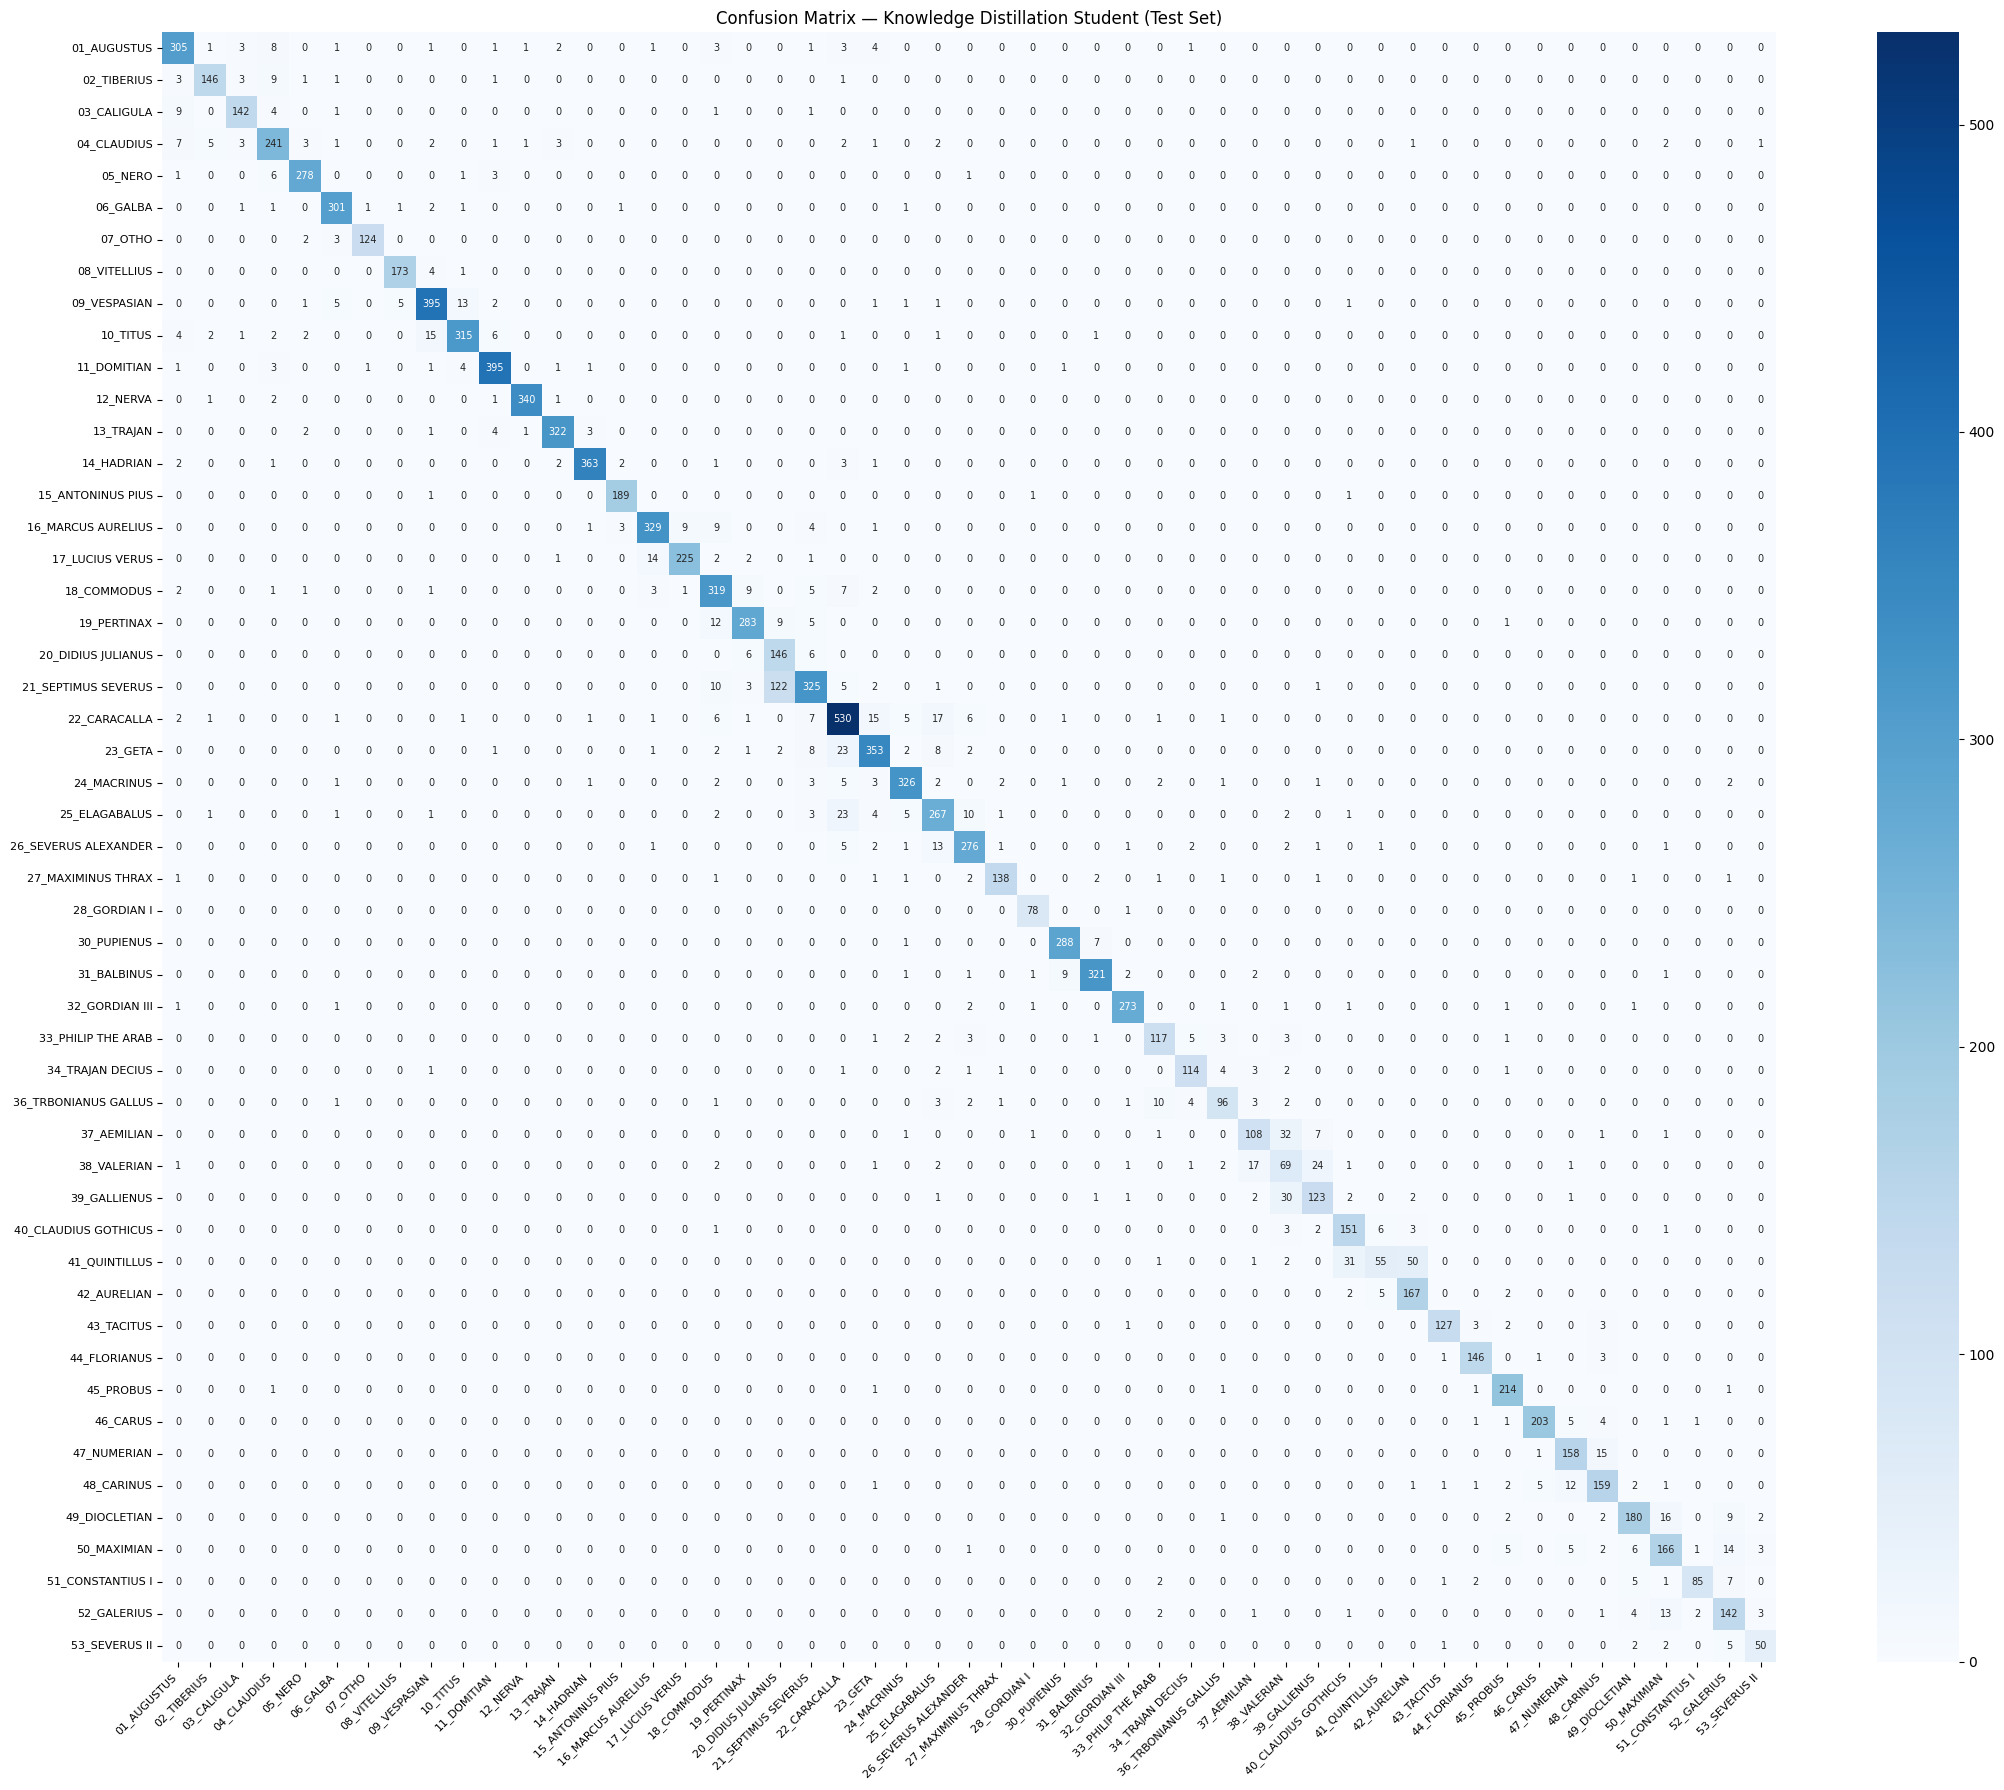

In [12]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}
class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix.get(idx_to_label[i], 99))
display_names = [f"{name_to_prefix.get(idx_to_label[i], 99):02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for imgs, _, hard_labels in test_loader:
        imgs, hard_labels = imgs.to(device), hard_labels.to(device)
        preds = student(imgs).argmax(-1)
        for t, p in zip(hard_labels.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
print(f'Overall: {cm.diagonal().sum()}/{cm.sum()} = {cm.diagonal().sum()/cm.sum():.4f}\n')
print('Per-class (worst first):')
for i in np.argsort(row_acc)[:10]:   # show 10 worst
    n_total = int(cm[i].sum()); n_correct = int(cm[i, i])
    print(f'{display_names[i]}: {n_correct}/{n_total}  ({n_correct/max(n_total,1):.1%})')
    off = sorted(((j, int(cm[i,j])) for j in range(num_classes) if j!=i and cm[i,j]>0), key=lambda x:-x[1])
    for j, cnt in off[:2]:
        print(f'  -> {display_names[j]}: {cnt} ({cnt/max(n_total,1):.1%})')

plt.figure(figsize=(22, 18))
sns.heatmap(pd.DataFrame(cm, index=display_names, columns=display_names),
            annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.title('Confusion Matrix — Knowledge Distillation Student (Test Set)')
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

---
## Section F — ONNX Export + int8 Quantization

Export the student as a single ONNX graph ready for `onnxruntime-web`.
No ensemble, no kNN, no switching — just one forward pass on a 224×224 image.

int8 quantization cuts the file from ~16MB (fp32) to ~4-5MB with negligible accuracy drop.

In [13]:
import onnx

student.eval().cpu()
dummy_input = torch.randn(1, 3, 224, 224)
onnx_path   = 'coin_classifier.onnx'

torch.onnx.export(
    student,
    dummy_input,
    onnx_path,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
    opset_version=17,
)
onnx.checker.check_model(onnx_path)
size_mb = Path(onnx_path).stat().st_size / 1e6
print(f'Exported: {onnx_path}  ({size_mb:.1f} MB fp32)')

ModuleNotFoundError: No module named 'onnx'

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

int8_path = 'coin_classifier_int8.onnx'
quantize_dynamic(
    onnx_path,
    int8_path,
    weight_type=QuantType.QInt8,
)
size_int8 = Path(int8_path).stat().st_size / 1e6
print(f'Quantized: {int8_path}  ({size_int8:.1f} MB int8)')
print(f'Size reduction: {size_mb:.1f}MB → {size_int8:.1f}MB  ({size_mb/size_int8:.1f}x smaller)')

In [ ]:
import onnxruntime as ort
import torchvision.transforms.functional as TF

# Verify ONNX output matches PyTorch output on a sample image
sample_img, _, sample_label = test_ds[0]
sample_input = sample_img.unsqueeze(0).numpy()

# PyTorch
with torch.no_grad():
    pt_logits = student(torch.tensor(sample_input))
    pt_pred   = pt_logits.argmax(-1).item()

# ONNX Runtime (fp32)
sess_fp32 = ort.InferenceSession(onnx_path)
ort_logits_fp32 = sess_fp32.run(None, {'image': sample_input})[0]
ort_pred_fp32   = ort_logits_fp32.argmax(-1)[0]

# ONNX Runtime (int8)
sess_int8 = ort.InferenceSession(int8_path)
ort_logits_int8 = sess_int8.run(None, {'image': sample_input})[0]
ort_pred_int8   = ort_logits_int8.argmax(-1)[0]

true_label = idx_to_label[sample_label.item()]
print(f'True label  : {true_label}')
print(f'PyTorch     : {idx_to_label[pt_pred]}')
print(f'ONNX fp32   : {idx_to_label[ort_pred_fp32]}')
print(f'ONNX int8   : {idx_to_label[ort_pred_int8]}')
max_diff = float(np.abs(pt_logits.numpy() - ort_logits_fp32).max())
print(f'Max logit diff (PyTorch vs ONNX fp32): {max_diff:.6f}')

In [ ]:
# Measure accuracy of ONNX int8 model on full test set
print('Evaluating ONNX int8 on test set...')
correct, total = 0, 0
for imgs, _, hard_labels in test_loader:
    logits = sess_int8.run(None, {'image': imgs.numpy()})[0]
    preds  = logits.argmax(-1)
    correct += (preds == hard_labels.numpy()).sum()
    total   += len(hard_labels)
int8_acc = correct / total
print(f'\nSummary:')
print(f'  Teacher (v6 full pipeline) : 92.71%')
print(f'  Student PyTorch            : {best_val_acc * 100:.2f}% val  /  {test_acc * 100:.2f}% test')
print(f'  Student ONNX int8          : {int8_acc * 100:.2f}% test')
print(f'  Model size                 : {size_int8:.1f} MB')
print(f'  Parameters                 : ~5.4M')

---
## Section G — Save Label Mapping for Deployment

The web app needs to map model output index → emperor name.
Save as both JSON (for JavaScript) and a simple text file.

In [ ]:
import json

# Map: output index → emperor name, ordered by model output index
idx_to_name = {str(i): name for i, name in idx_to_label.items()}

with open('coin_labels.json', 'w') as f:
    json.dump(idx_to_name, f, indent=2)
print('Saved coin_labels.json')

with open('coin_labels.txt', 'w') as f:
    for i in range(num_classes):
        f.write(f'{i}\t{idx_to_label[i]}\n')
print('Saved coin_labels.txt')

print(f'\nDeployment files ready:')
print(f'  coin_classifier_int8.onnx  — model ({size_int8:.1f} MB)')
print(f'  coin_labels.json           — label mapping for JavaScript')